# Spatial Analysis of Earthquake Damage (Noto Peninsula)

This project explores earthquake-induced building damage using geospatial data from the Noto Peninsula.

The main goal is to understand whether damage patterns can be explained using standard machine learning models, or if spatial methods are required.

---

## Dataset Overview

The dataset contains building-level information along with hazard indicators and spatial geometry.

| Attribute         | Type         | Description                                 |
| ----------------- | ------------ | ------------------------------------------- |
| fid               | Int64        | Unique identifier for each building         |
| s_fid             | String       | Feature identifier from original source     |
| damage            | Int8         | Raw damage class                            |
| damage_val        | Int8         | Validated damage class (used as target)     |
| municipality      | String       | Municipality name                           |
| conf              | String       | Confidence level of assessment              |
| GSI_fire          | Bool         | Fire-affected area indicator                |
| GSI_slope_failure | Bool         | Slope failure indicator                     |
| GSI_tsunami       | Bool         | Tsunami impact indicator                    |
| USGS_MMI          | Float        | Seismic intensity (Modified Mercalli Index) |
| geometry          | MultiPolygon | Building footprint geometry                 |

---

## Objectives

While working with this dataset, the focus is on:

- understanding the structure and quality of the data
- exploring how damage is distributed across space
- analyzing relationships between hazard indicators and damage
- checking whether damage is spatially clustered (autocorrelation)
- identifying variation across different regions (heterogeneity)

---

## Motivation

Initial observations suggest that:

- damage is not randomly distributed
- nearby buildings tend to show similar patterns
- global models struggle to capture the minority class

This raises an important question:

> Can a single global model explain damage everywhere,  
> or do relationships vary across locations?

To investigate this, the project moves from standard machine learning toward **spatial models**, particularly geographically weighted approaches (gwlearn).

---

## Current Status

This is an ongoing work.

So far:

- exploratory data analysis (EDA) is completed
- global models have been implemented and evaluated
- initial spatial modeling experiments have been conducted

However:

- bandwidth optimization is still in progress
- some spatial models are computationally expensive and not fully executed

The current results already highlight key challenges, especially around:

- class imbalance
- spatial dependency
- computational cost of local models

---

## Direction

The next steps focus on:

- improving spatial model scalability
- refining bandwidth selection strategies

The overall aim is to better understand how spatial structure can be incorporated into machine learning models for real-world datasets.


## Setup and Imports

The analysis uses geospatial and statistical libraries to explore spatial patterns in earthquake-induced building damage.

- `geopandas` for spatial data handling
- `libpysal` and `esda` for spatial statistics
- `matplotlib` and `seaborn` for visualization
- `scikit-learn` for later modeling steps


In [ ]:
# import required libraries
import geopandas as gpd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from libpysal.weights import KNN
from esda.moran import Moran

import warnings
warnings.filterwarnings('ignore')

# import for global model
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# import for spatial model
from gwlearn.ensemble import GWRandomForestClassifier, GWGradientBoostingClassifier
from gwlearn.linear_model import GWLogisticRegression
from gwlearn.search import BandwidthSearch
from sklearn import metrics as sk_metrics

## Data Loading and Initial Inspection

The dataset contains building-level damage information from the Noto Peninsula earthquake, along with hazard indicators and spatial geometry.

The data is converted to a projected coordinate system (EPSG:3857) to allow spatial computations such as distance-based analysis.


In [4]:
# Loading dataset
df = gpd.read_file("Noto_Peninsula_Damage_2_5.gpkg", layer='v2.5')

# Use geographic CRS (important for spatial reasoning)
gdf = df.to_crs(epsg=3857)

In [5]:
gdf.head()

,s_fid,source,damage_val,municipality,conf,damage_2,GSI_fire,GSI_tsunami,GSI_slope_failure,USGS_MMI,geometry
0,20230303-49413-13440-s-302,None,0,石川県、能登町、字四方山,single,0,0,1,0,8.4,"MULTIPOLYGON (((15280382.939 4486369.094, 1528..."
1,20230303-49413-13440-s-350,None,0,石川県、能登町、字立壁,single,0,0,1,0,8.4,"MULTIPOLYGON (((15280341.176 4486564.137, 1528..."
2,20230303-49281-13458-s-5042,143,0,石川県、輪島市、南町,single,0,0,0,0,8.4,"MULTIPOLYGON (((15239022.643 4493501.009, 1523..."
3,20230303-49281-13464-s-3195,129,0,石川県、輪島市、輪島崎町仲町,multi,0,0,0,0,8.2,"MULTIPOLYGON (((15239532.521 4495483.664, 1523..."
4,20230303-49281-13461-s-7325,None,0,石川県、輪島市、鳳至町稲荷西一,multi,0,0,0,0,8.4,"MULTIPOLYGON (((15239059.66 4494043.076, 15239..."


In [6]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 140208 entries, 0 to 140207
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   s_fid              140208 non-null  object  
 1   source             4888 non-null    object  
 2   damage_val         140208 non-null  int32   
 3   municipality       140186 non-null  object  
 4   conf               139895 non-null  object  
 5   damage_2           140208 non-null  int32   
 6   GSI_fire           140208 non-null  int64   
 7   GSI_tsunami        140208 non-null  int64   
 8   GSI_slope_failure  140208 non-null  int64   
 9   USGS_MMI           140208 non-null  float64 
 10  geometry           140208 non-null  geometry
dtypes: float64(1), geometry(1), int32(2), int64(3), object(4)
memory usage: 10.7+ MB


In [7]:
gdf.isnull().sum()

,0
s_fid,0
source,135320
damage_val,0
municipality,22
conf,313
damage_2,0
GSI_fire,0
GSI_tsunami,0
GSI_slope_failure,0
USGS_MMI,0


In [8]:
gdf.describe()

,damage_val,damage_2,GSI_fire,GSI_tsunami,GSI_slope_failure,USGS_MMI
count,140208.000000,140208.000000,140208.000000,140208.000000,140208.000000,140208.000000
mean,11.246569,11.269928,0.002218,0.024378,0.001205,8.259644
std,30.495799,30.524045,0.047045,0.154220,0.034697,0.382742
min,0.000000,0.000000,0.000000,0.000000,0.000000,7.200000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,8.400000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,8.600000
max,99.000000,99.000000,1.000000,1.000000,1.000000,9.000000


The dataset contains over 140k building records with both attribute and spatial information.

Key observations:

- Most columns are complete, except `source` which has many missing values
- Damage labels include multiple categories (0, 1, 9, 99), requiring cleaning
- Hazard indicators are binary features
- Geometry is available for all records, enabling spatial analysis


In [9]:
# Dropping irrelevant columns
gdf = gdf.drop(columns=["s_fid", "source", "damage_2"], errors="ignore")

In [10]:
gdf['damage_val'].value_counts()

,count
damage_val,
0,112275
99,15035
9,9437
1,3461


In [11]:
# Removing invalid label (9 or 99)
gdf = gdf[~gdf["damage_val"].isin([9, 99])].copy()

# converting to int8
gdf["damage_val"] = gdf["damage_val"].astype("int8")

#### Data Cleaning

Damage labels include values such as 9 and 99, which do not correspond to valid classes for modeling. These are removed to create a clean binary classification setup.

Additional preprocessing steps:

- Missing municipality values are dropped
- Missing confidence values are filled with "unknown"
- Hazard features are converted to compact integer types
- Municipality names are cleaned for grouping and analysis


In [12]:
# removing null values
gdf = gdf.dropna(subset=["municipality"])

In [13]:
# filling null values with 'unknown'
gdf["conf"] = gdf["conf"].fillna("unknown")

In [14]:
# converting hazard columns to 'int8'
hazard_cols = ["GSI_fire", "GSI_tsunami", "GSI_slope_failure"]
gdf[hazard_cols] = gdf[hazard_cols].astype("int8")

In [15]:
# exracting municipality
gdf["municipality_clean"] = gdf["municipality"].str.split("、").str[1]
gdf["municipality_clean"].isnull().sum()

np.int64(0)

Invalid geometries (if any) are corrected using a zero-distance buffer. This ensures that spatial operations such as centroid calculation and spatial weights construction work correctly.


In [16]:
# validating geometry
invalid = ~gdf.is_valid
gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)
print("Invalid geometries:", invalid.sum())

Invalid geometries: 0


In [17]:
print(gdf.shape)

gdf[[
    "damage_val",
    "USGS_MMI",
    "GSI_fire",
    "GSI_tsunami",
    "GSI_slope_failure"
]].describe()

(115727, 9)


,damage_val,USGS_MMI,GSI_fire,GSI_tsunami,GSI_slope_failure
count,115727.000000,115727.000000,115727.000000,115727.000000,115727.000000
mean,0.029889,8.232209,0.002687,0.026856,0.000734
std,0.170283,0.387084,0.051770,0.161664,0.027092
min,0.000000,7.200000,0.000000,0.000000,0.000000
25%,0.000000,7.800000,0.000000,0.000000,0.000000
50%,0.000000,8.400000,0.000000,0.000000,0.000000
75%,0.000000,8.600000,0.000000,0.000000,0.000000
max,1.000000,9.000000,1.000000,1.000000,1.000000


In [18]:
gdf.head(3)

,damage_val,municipality,conf,GSI_fire,GSI_tsunami,GSI_slope_failure,USGS_MMI,geometry,municipality_clean
0,0,石川県、能登町、字四方山,single,0,1,0,8.4,"MULTIPOLYGON (((15280382.939 4486369.094, 1528...",能登町
1,0,石川県、能登町、字立壁,single,0,1,0,8.4,"MULTIPOLYGON (((15280341.176 4486564.137, 1528...",能登町
2,0,石川県、輪島市、南町,single,0,0,0,8.4,"MULTIPOLYGON (((15239022.643 4493501.009, 1523...",輪島市


damage_val
0    0.970111
1    0.029889
Name: proportion, dtype: float64


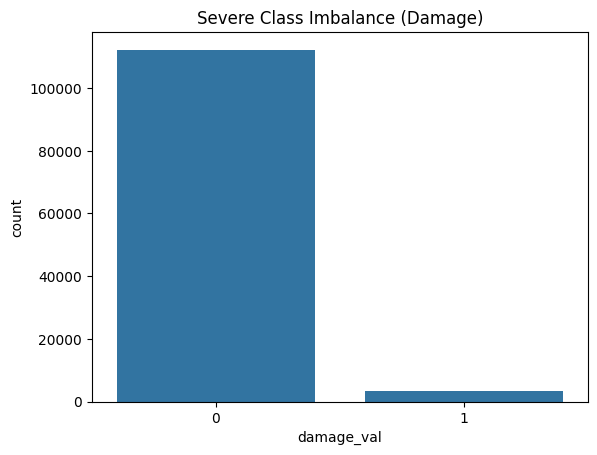

In [19]:
# plotting target distribution
target = "damage_val"
print(gdf[target].value_counts(normalize=True))

sns.countplot(x=target, data=gdf)
plt.title("Severe Class Imbalance (Damage)")
plt.show()

#### Class Distribution

The dataset is highly imbalanced, with approximately 97% of buildings classified as non-damaged and only ~3% as damaged.

This imbalance makes standard classification challenging, as models tend to favor the majority class. It also affects evaluation metrics, making accuracy unreliable and requiring metrics such as PR-AUC and F1-score.


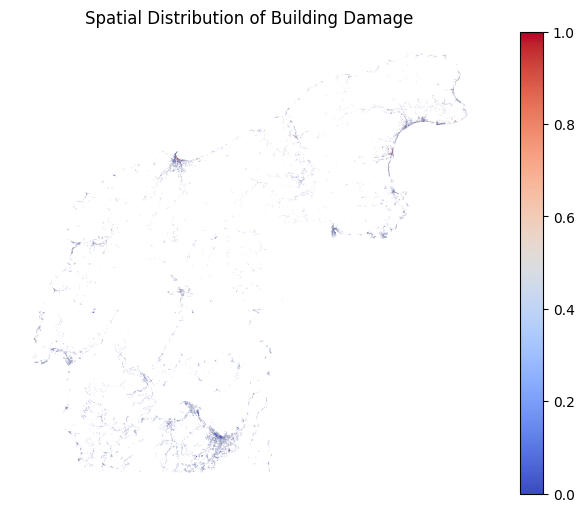

In [20]:
# plotting spatial distribution of damage
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

gdf.plot(
    column=target,
    cmap="coolwarm",
    markersize=1,
    legend=True,
    ax=ax
)
ax.set_title("Spatial Distribution of Building Damage")
ax.axis("off")
plt.show()

#### Spatial Distribution of Damage

Damage is not randomly distributed across space and appears to form clusters.

This suggests that nearby buildings may share similar damage patterns, indicating spatial dependency and violation of the independence assumption used in standard machine learning models.


In [21]:
# creating coordinates
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = list(zip(gdf["x"], gdf["y"]))

#### Spatial Weights Construction

To quantify spatial relationships, a k-nearest neighbors (KNN) graph is constructed using building centroids.

Each building is connected to its 50 nearest neighbors, and weights are row-standardized to ensure comparability.


In [22]:
# spatial weights
W = KNN.from_array(coords, k=50)
W.transform = "r"

print("Number of connected components: ", W.n_components)

Number of connected components:  13


The presence of multiple disconnected components in the spatial weights matrix suggests that the dataset is not fully spatially connected, which can affect local model estimation


In [23]:
# assigning components
gdf['component'] = W.component_labels

In [24]:
# analysing components
component_sizes = pd.Series(W.component_labels).value_counts().sort_values(ascending=False)
print(component_sizes.head())

0     111914
1        839
4        757
10       619
9        425
Name: count, dtype: int64


In [25]:
gdf.groupby("component")["municipality_clean"].nunique().head()

,municipality_clean
component,
0,7
1,1
2,1
3,1
4,1


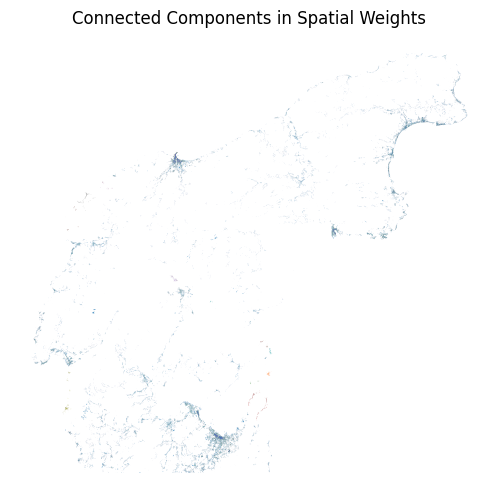

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

gdf.plot(
    column="component",
    categorical=True,
    legend=False,
    markersize=1,
    ax=ax
)

ax.set_title("Connected Components in Spatial Weights")
ax.axis("off")
plt.show()

In [27]:
# spatial correlation
y = gdf[target].values
moran = Moran(y, W)
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.28267254094514055
p-value: 0.001


#### Spatial Autocorrelation (Moran's I)

Moran’s I is used to measure spatial autocorrelation in the target variable.

A value of ~0.28 with a statistically significant p-value (< 0.01) indicates strong positive spatial autocorrelation.

This confirms that damage is spatially clustered rather than randomly distributed.


In [28]:
hazard_cols = ["GSI_fire", "GSI_tsunami", "GSI_slope_failure"]

for col in hazard_cols:
    print(f"\n{col}")
    display(
        gdf.groupby(col)[target]
        .agg(["mean", "count"])
    )


GSI_fire


,mean,count
GSI_fire,,
0,0.027275,115416
1,1.000000,311



GSI_tsunami


,mean,count
GSI_tsunami,,
0,0.024863,112619
1,0.212033,3108



GSI_slope_failure


,mean,count
GSI_slope_failure,,
0,0.029635,115642
1,0.376471,85


#### Relationship with Hazard Indicators

Damage rates are significantly higher in areas affected by hazards such as tsunami and slope failure.

For example:

- Buildings within tsunami zones show much higher damage rates
- Slope failure areas also show strong association with damage

This suggests that hazard features are important predictors, but may interact with spatial context.


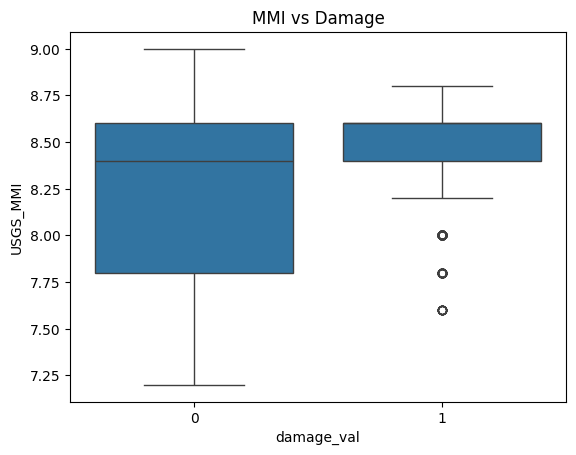

In [29]:
sns.boxplot(x=target, y="USGS_MMI", data=gdf)
plt.title("MMI vs Damage")
plt.show()

#### Seismic Intensity (MMI) Analysis

Higher seismic intensity (MMI) is generally associated with increased damage.

However, variability within each class suggests that MMI alone does not fully explain damage patterns, indicating the influence of additional spatial or contextual factors.


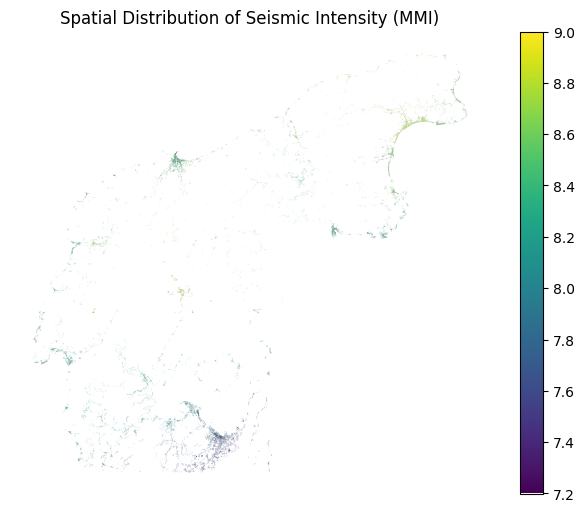

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

gdf.plot(
    column="USGS_MMI",
    cmap="viridis",
    legend=True,
    markersize=1,
    ax=ax
)

ax.set_title("Spatial Distribution of Seismic Intensity (MMI)")
ax.axis("off")
plt.show()

In [31]:
muni_stats = (
    gdf.groupby("municipality_clean")[target]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

muni_stats.head(10)

,mean,count
municipality_clean,,
珠洲市,0.091531,19305
輪島市,0.063328,20686
穴水町,0.020052,3840
能登町,0.008423,13415
志賀町,0.004644,16364
七尾市,0.002861,40551
中能登町,0.000000,1566


#### Regional (Municipality-Level) Variation

- Damage rates vary significantly across municipalities.
- This indicates spatial heterogeneity, where different regions exhibit different relationships between predictors and damage outcomes.
- Such variation cannot be captured by a single global model.


In [32]:
damage_rate = gdf[target].mean()
print("Overall damage rate:", damage_rate)

Overall damage rate: 0.029889308458700217


In [33]:
gdf.head(2)

,damage_val,municipality,conf,GSI_fire,GSI_tsunami,GSI_slope_failure,USGS_MMI,geometry,municipality_clean,centroid,x,y,component
0,0,石川県、能登町、字四方山,single,0,1,0,8.4,"MULTIPOLYGON (((15280382.939 4486369.094, 1528...",能登町,POINT (15280399.707 4486363.635),1.528040e+07,4.486364e+06,0
1,0,石川県、能登町、字立壁,single,0,1,0,8.4,"MULTIPOLYGON (((15280341.176 4486564.137, 1528...",能登町,POINT (15280347.067 4486560.625),1.528035e+07,4.486561e+06,0


#### Key Takeaways from EDA

- The dataset is highly imbalanced (~97:3), making classification challenging
- Damage is spatially clustered (Moran’s I ≈ 0.28), violating independence assumptions
- Hazard indicators are strongly associated with damage but vary spatially
- Significant variation across municipalities suggests spatial heterogeneity

These observations highlight the limitations of global machine learning models and motivate the use of spatially adaptive approaches such as geographically weighted models.


### Modeling — Part 1: Global Model (Baseline)

Before applying spatial models, a standard (non-spatial) machine learning baseline is built.

The goal here is to:

- understand how well global models perform on this dataset
- establish a reference point for comparison with spatial models

Given the strong class imbalance (~97% vs ~3%), the models incorporate:

- class weighting (`class_weight='balanced'`)
- manual SMOTE for oversampling

This baseline is important because gwlearn models also internally fit a global model (`fit_global_model=True`), so this section provides a direct comparison.


#### Feature Engineering and Data Split

The dataset is split into training and testing sets using a **group-based split**.

Instead of random splitting, municipalities are kept intact to avoid spatial leakage.
This ensures that nearby observations from the same region do not appear in both train and test sets.

Additional features are created to capture:

- local risk (municipality/component damage rates)
- interactions between hazards and seismic intensity
- aggregated hazard signals


In [34]:
# Feature Engineering
target = "damage_val"

base_features = ["USGS_MMI", "GSI_fire", "GSI_tsunami", "GSI_slope_failure"]

# Spatial train/test split and keeping municipalities whole
groups = gdf["municipality_clean"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(gdf, gdf[target], groups=groups))
train = gdf.iloc[train_idx].copy()
test  = gdf.iloc[test_idx].copy()

print(f"Train: {len(train):,}  |  Test: {len(test):,}")
print(f"Train class balance → {train[target].value_counts(normalize=True).round(4).to_dict()}")


Train: 73,610  |  Test: 42,117
Train class balance → {0: 0.9546, 1: 0.0454}


- The dataset remains highly imbalanced even after splitting, with only ~4.5% minority class in the training set.
- This imbalance is expected to make learning difficult, especially for models that rely on global decision boundaries.


In [35]:
# Target encoding & interaction features
muni_rate = train.groupby("municipality_clean")[target].mean()
comp_rate = train.groupby("component")[target].mean()

for df in [train, test]:
    df["muni_damage_rate"] = df["municipality_clean"].map(muni_rate).fillna(muni_rate.mean())
    df["comp_damage_rate"] = df["component"].map(comp_rate).fillna(comp_rate.mean())
    for col in ["GSI_fire", "GSI_tsunami", "GSI_slope_failure"]:
        df[f"{col}_mmi"] = df[col] * df["USGS_MMI"]
    df["mmi_log"]       = np.log1p(df["USGS_MMI"])
    df["any_hazard"]    = (df[["GSI_fire","GSI_tsunami","GSI_slope_failure"]].sum(axis=1) > 0).astype(int)
    df["hazard_count"]  = df[["GSI_fire","GSI_tsunami","GSI_slope_failure"]].sum(axis=1)
    df["mmi_x_hazard"]  = df["USGS_MMI"] * df["any_hazard"]
    df["risk_composite"]= df["muni_damage_rate"] * df["USGS_MMI"]

features = base_features + [
    "muni_damage_rate", "comp_damage_rate", "mmi_log",
    "GSI_fire_mmi", "GSI_tsunami_mmi", "GSI_slope_failure_mmi",
    "any_hazard", "hazard_count", "mmi_x_hazard", "risk_composite"
]

X_train = train[features].values
X_test  = test[features].values
y_train = train[target].values
y_test  = test[target].values

print(f"Feature matrix — Train: {X_train.shape}, Test: {X_test.shape}")

Feature matrix — Train: (73610, 14), Test: (42117, 14)


- The final feature set includes both original hazard indicators and engineered features capturing interactions and regional effects.
- The resulting feature matrix has 14 features, which are used for all global models.


#### Handling Class Imbalance

- To address the severe imbalance, a manual implementation of SMOTE is used.
- Synthetic samples are generated for the minority class using nearest neighbors, increasing its representation in the training data.


In [36]:
# Manual SMOTE
def manual_smote(X, y, minority_class=1, k=5, random_state=42):
    rng = np.random.default_rng(random_state)
    X_min = X[y == minority_class]
    n_needed = (y != minority_class).sum() - len(X_min)
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    _, indices = nn.kneighbors(X_min)
    synthetic = []
    for _ in range(n_needed):
        i = rng.integers(0, len(X_min))
        nb = indices[i, rng.integers(1, k + 1)]
        synthetic.append(X_min[i] + rng.random() * (X_min[nb] - X_min[i]))
    X_res = np.vstack([X, np.array(synthetic)])
    y_res = np.concatenate([y, np.ones(n_needed, dtype=y.dtype)])
    perm = rng.permutation(len(X_res))
    return X_res[perm], y_res[perm]

X_smote, y_smote = manual_smote(X_train, y_train)
print(f"Original  → {y_train.mean():.2%} minority")
print(f"After SMOTE→ {y_smote.mean():.2%} minority")

Original  → 4.54% minority
After SMOTE→ 50.00% minority


- After applying SMOTE, the minority class is artificially balanced to 50%.
- However, this does not guarantee improved performance, especially if the underlying patterns are not well captured by global models.


In [37]:
# Transform data
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

#### Global Model Training

Three different models are trained to capture different types of relationships:

- Logistic Regression → linear baseline
- Random Forest → non-linear ensemble model
- HistGradientBoosting → more flexible boosting-based model

Additionally, a manual stacking approach is implemented to combine predictions from multiple models.


In [38]:
# Global Models
lr = LogisticRegression(class_weight='balanced', max_iter=2000, C=0.5, random_state=42)
lr.fit(X_tr_sc, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                             class_weight='balanced_subsample', n_jobs=1, random_state=42)
rf.fit(X_train, y_train)

hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, max_depth=6,
                                      min_samples_leaf=20, class_weight='balanced',
                                      early_stopping=True, n_iter_no_change=20,
                                      random_state=42)
hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(class_weight='balanced', early_stopping=True,
                               learning_rate=0.05, max_depth=6, max_iter=500,
                               n_iter_no_change=20, random_state=42)

- Stacking is performed using out-of-fold (OOF) predictions to avoid data leakage.
- Each base model is trained using cross-validation, and their predictions are used as input to a meta-model (logistic regression).


In [39]:
# Manual stack via OOF
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lr = np.zeros(len(y_train))
oof_rf = np.zeros(len(y_train))
oof_hgb= np.zeros(len(y_train))

for tr_idx, val_idx in skf.split(X_train, y_train):
    sc_f = StandardScaler()
    lr_f = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5)
    lr_f.fit(sc_f.fit_transform(X_train[tr_idx]), y_train[tr_idx])
    oof_lr[val_idx] = lr_f.predict_proba(sc_f.transform(X_train[val_idx]))[:,1]

    rf_f = RandomForestClassifier(n_estimators=100, max_depth=10,
                                   class_weight='balanced_subsample', n_jobs=1, random_state=42)
    rf_f.fit(X_train[tr_idx], y_train[tr_idx])
    oof_rf[val_idx] = rf_f.predict_proba(X_train[val_idx])[:,1]

    hgb_f = HistGradientBoostingClassifier(max_iter=200, class_weight='balanced',
                                            learning_rate=0.05, random_state=42)
    hgb_f.fit(X_train[tr_idx], y_train[tr_idx])
    oof_hgb[val_idx] = hgb_f.predict_proba(X_train[val_idx])[:,1]

meta_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
meta_lr.fit(np.column_stack([oof_lr, oof_rf, oof_hgb]), y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
def find_threshold(y_true, y_prob):
    p, r, th = precision_recall_curve(y_true, y_prob)
    f1 = 2*(p*r)/(p+r+1e-8)
    idx = np.argmax(f1[:-1])
    return th[idx]

#### Evaluation

Given the class imbalance, standard accuracy is not informative.

Instead, the following metrics are used:

- F1-score (minority class)
- PR-AUC (precision-recall area, more suitable for imbalance)
- ROC-AUC
- Top-5% recall (ability to capture highest-risk cases)

A custom threshold is selected based on maximizing F1-score.


In [41]:
# Global Model Evaluation
def evaluate(name, y_true, y_prob):
    th = find_threshold(y_true, y_prob)
    y_pred = (y_prob >= th).astype(int)
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(classification_report(y_true, y_pred, zero_division=0,
                                 target_names=["No Damage","Destroyed"]))
    f1      = f1_score(y_true, y_pred, zero_division=0)
    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    k = int(len(y_true)*0.05)
    top5r = y_true[np.argsort(y_prob)[-k:]].mean()
    print(f"  F1 (minority): {f1:.4f}  |  PR-AUC: {pr_auc:.4f}  |  ROC-AUC: {roc_auc:.4f}  |  Top-5% Recall: {top5r:.4f}")
    return dict(model=name, f1=f1, pr_auc=pr_auc, roc_auc=roc_auc, top5_recall=top5r)


In [42]:
y_prob_lr  = lr.predict_proba(X_te_sc)[:,1]
y_prob_rf  = rf.predict_proba(X_test)[:,1]
y_prob_hgb = hgb.predict_proba(X_test)[:,1]
meta_test  = np.column_stack([lr.predict_proba(X_te_sc)[:,1],
                               rf.predict_proba(X_test)[:,1],
                               hgb.predict_proba(X_test)[:,1]])
y_prob_stack = meta_lr.predict_proba(meta_test)[:,1]
y_prob_blend = (y_prob_lr + y_prob_rf + y_prob_hgb + y_prob_stack) / 4

global_results = []
for name, probs in [("Logistic Regression", y_prob_lr),
                    ("Random Forest",        y_prob_rf),
                    ("HistGradientBoosting", y_prob_hgb),
                    ("Manual Stack",         y_prob_stack),
                    ("Blend (avg)",          y_prob_blend)]:
    global_results.append(evaluate(name, y_test, probs))

global_df = pd.DataFrame(global_results).set_index("model").sort_values("pr_auc", ascending=False)
print("\n Global Model Summary (sorted by PR-AUC) ")
print(global_df.round(4).to_string())


  Logistic Regression
              precision    recall  f1-score   support

   No Damage       1.00      1.00      1.00     42001
   Destroyed       0.12      0.01      0.02       116

    accuracy                           1.00     42117
   macro avg       0.56      0.50      0.51     42117
weighted avg       0.99      1.00      1.00     42117

  F1 (minority): 0.0161  |  PR-AUC: 0.0054  |  ROC-AUC: 0.6152  |  Top-5% Recall: 0.0024

  Random Forest
              precision    recall  f1-score   support

   No Damage       1.00      1.00      1.00     42001
   Destroyed       0.50      0.01      0.02       116

    accuracy                           1.00     42117
   macro avg       0.75      0.50      0.51     42117
weighted avg       1.00      1.00      1.00     42117

  F1 (minority): 0.0169  |  PR-AUC: 0.0093  |  ROC-AUC: 0.6804  |  Top-5% Recall: 0.0024

  HistGradientBoosting
              precision    recall  f1-score   support

   No Damage       1.00      1.00      1.00     4

### Results and Observations

Across all models, performance on the minority class is extremely poor:

- F1-score ≈ 0.017
- PR-AUC ≈ 0.01
- Recall is close to zero

Despite:

- class weighting
- SMOTE
- feature engineering
- ensemble methods

the models fail to identify damaged buildings effectively.

Even the best model (HistGradientBoosting) achieves very low PR-AUC, only slightly above baseline.

This suggests that the limitation is not only due to class imbalance.

Instead, the failure indicates that global models are unable to capture the underlying structure of the data, particularly spatial dependencies and local variation.

In a global model, a single set of parameters is applied across all locations.

However, the earlier EDA showed:

- strong spatial clustering (Moran’s I ≈ 0.28)
- variation across municipalities

This indicates that relationships between features and damage are not uniform across space.

As a result, global models tend to average out local patterns, leading to poor performance on rare but spatially concentrated events.


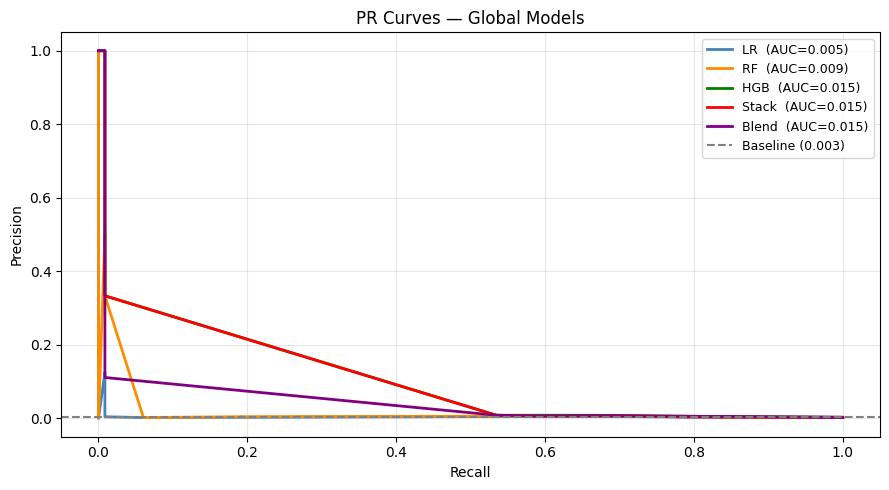

In [43]:
# Precision-Recall curves of Global Models
fig, ax = plt.subplots(figsize=(9, 5))
for (name, probs), c in zip([("LR", y_prob_lr),("RF", y_prob_rf),
                               ("HGB", y_prob_hgb),("Stack", y_prob_stack),
                               ("Blend", y_prob_blend)],
                              ['steelblue','darkorange','green','red','purple']):
    p, r, _ = precision_recall_curve(y_test, probs)
    ax.plot(r, p, lw=2, label=f"{name}  (AUC={average_precision_score(y_test,probs):.3f})", color=c)
ax.axhline(y_test.mean(), color='grey', ls='--', label=f"Baseline ({y_test.mean():.3f})")
ax.set(xlabel="Recall", ylabel="Precision", title="PR Curves — Global Models")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The precision-recall curves further confirm this behavior.

All models remain close to the baseline, indicating limited ability to distinguish the minority class.

This reinforces the observation that global models are not sufficient for this task.


### Modeling — Part 2: Spatial Models (gwlearn)

From the EDA and global modeling results, two things became clear:

- Damage is spatially clustered (Moran’s I ≈ 0.28)
- Global models fail to capture the minority class effectively

This suggests that the relationship between features and damage is not constant across space.

To address this, geographically weighted (GW) models are used.  
Instead of fitting a single global model, GW models fit a separate local model for each building using nearby observations.

This allows the model to capture local variation, where different regions may behave differently.


### Key Parameters

- `bandwidth` → controls size of local neighbourhood
- `fixed=False` → adaptive bandwidth (same number of neighbours everywhere)
- `kernel='bisquare'` → closer points get higher weight
- `min_proportion` → skip locations with too few minority samples
- `undersample=True` → balance local datasets
- `fit_global_model=True` → also fits a global model for comparison


#### Data Preparation for gwlearn

gwlearn expects:

- `X` → feature DataFrame
- `y` → binary target
- `geometry` → point geometry

A separate GeoDataFrame is prepared for spatial modeling. Duplicate coordinate points are removed to avoid issues during local model fitting.


In [ ]:
# Using a SUBSET for bandwidth search (full ~58k rows is expensive)
# After finding optimal bandwidth, refit on full training data

# Merge features back onto gdf slices
train_gdf = train.copy()
test_gdf  = test.copy()

train_gdf = train_gdf.drop_duplicates(subset=["x", "y"])

train_gdf = train_gdf.reset_index(drop=True)

# Binary target (damage_val is already 0/1)
y_train_gw = train_gdf[target].astype(int)
y_test_gw  = test_gdf[target].astype(int)

X_train_gw = train_gdf[features]
X_test_gw  = test_gdf[features]

# Geometry (already computed during eda)
train_geom = train_gdf["centroid"]
test_geom  = test_gdf["centroid"]

print(f"Train GW: {X_train_gw.shape} | minority: {y_train_gw.mean():.2%}")
print(f"Test  GW: {X_test_gw.shape}  | minority: {y_test_gw.mean():.2%}")


Train GW: (73589, 14) | minority: 4.54%
Test  GW: (42117, 14)  | minority: 0.28%


#### Step 1 — Bandwidth Selection

Bandwidth determines how many neighbours are used in each local model.

Choosing the right bandwidth is critical:

- Too small → unstable models (not enough data locally)
- Too large → behaves like a global model

A search is performed to find a bandwidth that minimizes log-loss.


#### Computational Note

Bandwidth search is computationally expensive because for each candidate bandwidth,
a full set of local models must be fitted.

Even with subsampling (~58k rows), this process can take a very long time.


In [47]:
# Bandwidth Search
""" dataset has 12 buildings sharing identical coordinates (coplanar points).
 libpysal raises CoplanarError when bandwidth < number of points at one site.
 Fix: pass coplanar='clique' — treats duplicates as a fully-connected clique.
 This kwarg flows through BandwidthSearch → GWRandomForestClassifier → libpysal.
"""


# Stratified subsample to keep minority class represented
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
sub_idx, _ = next(sss.split(X_train_gw, y_train_gw))
X_sub    = X_train_gw.iloc[sub_idx]
y_sub    = y_train_gw.iloc[sub_idx]
geom_sub = train_geom.iloc[sub_idx]

print(f"Bandwidth search subsample: {len(X_sub):,} rows  ({y_sub.mean():.2%} minority)")

search = BandwidthSearch(
    GWRandomForestClassifier,
    fixed=False,               # adaptive k-NN bandwidth
    kernel="bisquare",
    min_proportion=0.05,       # permissive — critical for 3% minority
    undersample=True,          # balance each local model
    n_jobs=1,                  # avoid parallel memory blow-up
    search_method="interval",
    min_bandwidth=100,
    max_bandwidth=500,
    interval=50,
    metrics=["log_loss", "prediction_rate"],
    criterion="log_loss",
    verbose=True,
    random_state=42,     # handles the 12 duplicate-coordinate buildings
    # sklearn RF kwargs passed through to each local model:
    n_estimators=100,
    max_depth=8,
    class_weight="balanced_subsample",
)
search.fit(X_sub, y_sub, geometry=geom_sub)

print(f"\nOptimal bandwidth: {search.optimal_bandwidth_}")
print("\nSearch metrics:")
print(search.metrics_.round(4))

Bandwidth search subsample: 58,871 rows  (4.54% minority)


KeyboardInterrupt: 

#### Interrupted Execution

The bandwidth search was manually interrupted due to long execution time.

This is expected for geographically weighted models, where:

- a separate model is fitted at each location
- and this process is repeated for multiple bandwidth values

Given the dataset size (~70k+ points), exhaustive search becomes computationally expensive.

To proceed with experimentation, a fallback bandwidth is used.


In [50]:
# get the attribute with a default value
optimal_bandwidth_ = getattr(search, 'optimal_bandwidth_', 200)

Since the optimal bandwidth could not be obtained within reasonable time,
a provisional value (k = 200) is used.

This allows testing of the spatial modeling pipeline while bandwidth optimization remains ongoing work.


Bandwidth search scores not available for plotting.


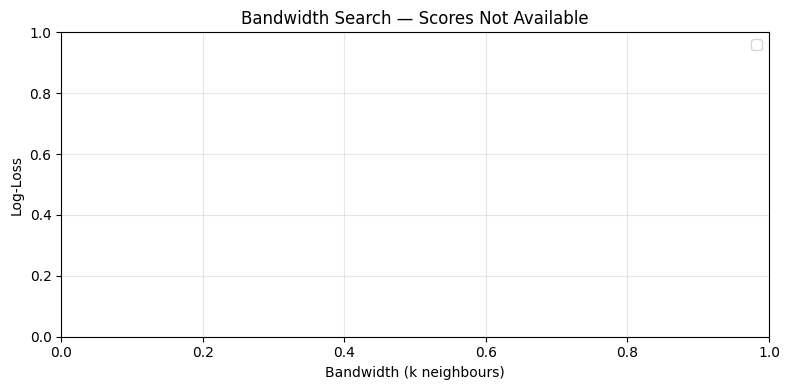


Using bandwidth = 200


In [53]:
# Plot bandwidth search scores
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Safely try to plot scores, handle if not available
if hasattr(search, 'scores_') and search.scores_ is not None:
    search.scores_.plot(ax=ax, marker='o', color='steelblue')
    ax.axvline(search.optimal_bandwidth_, color='red', ls='--',
        label=f"Optimal = {search.optimal_bandwidth_}")
else:
    print("Bandwidth search scores not available for plotting.")
    ax.set_title("Bandwidth Search — Scores Not Available")

ax.set(xlabel="Bandwidth (k neighbours)", ylabel="Log-Loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Ensure optimal_bw is defined using the fallback value from HU3FSruP4aQq
optimal_bw = int(optimal_bandwidth_)

print(f"\nUsing bandwidth = {optimal_bw}")

#### Step 2 — Fitting Spatial Models

Three geographically weighted models are attempted:

- GW Logistic Regression (lighter, faster)
- GW Random Forest (more complex)
- GW Gradient Boosting (most computationally expensive)

Due to computational constraints, not all models complete successfully.


#### GW Logistic Regression

This is the simplest spatial model and serves as a baseline for geographically weighted approaches.


In [55]:
# Geographically Weighted Logistic Regression

gw_lr = GWLogisticRegression(
    bandwidth=optimal_bw,
    fixed=False,
    kernel='bisquare',
    min_proportion=0.05,
    undersample=True,
    fit_global_model=True,
    n_jobs=1,
    random_state=42,
    class_weight='balanced',
    max_iter=500,
)
gw_lr.fit(X_train_gw, y_train_gw, geometry=train_geom)
print(f'prediction_rate={gw_lr.prediction_rate_:.2%}')

prediction_rate=25.62%


The model achieves a prediction rate of ~25%.

This means that local models could only be fitted for about 25% of locations.

The main reason is class imbalance:
many local neighbourhoods do not contain enough minority samples,
causing those locations to be skipped.

This highlights a key challenge in spatial modeling of imbalanced data:
local models require sufficient representation of all classes.


#### GW Random Forest

This model is significantly more computationally expensive because
a Random Forest is trained at each location.

The fitting process was manually interrupted due to long execution time.


In [56]:
# Geographically Weighted Random Forest

gw_rf = GWRandomForestClassifier(
    bandwidth=optimal_bw,
    fixed=False,
    kernel='bisquare',
    min_proportion=0.05,
    undersample=True,
    fit_global_model=True,
    n_jobs=1,
    random_state=42,
    n_estimators=100,
    max_depth=8,
    class_weight='balanced_subsample',
)
gw_rf.fit(X_train_gw, y_train_gw, geometry=train_geom)
print(f'prediction_rate={gw_rf.prediction_rate_:.2%}')

KeyboardInterrupt: 

Given the dataset size, fitting thousands of local ensemble models becomes infeasible
without further optimization (e.g., subsampling or parallelization).

This reinforces the need for scalable implementations of spatial models.


#### GW Gradient Boosting

Similar to Random Forest, this model is computationally intensive.

The fitting process was also interrupted due to excessive runtime.

This confirms that more complex spatial models require careful design
to remain computationally feasible.


In [57]:
# Geographically Weighted Gradient Boosting

gw_gb = GWGradientBoostingClassifier(
    bandwidth=optimal_bw,
    fixed=False,
    kernel='bisquare',
    min_proportion=0.05,
    undersample=True,
    fit_global_model=True,
    n_jobs=1,
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
)
gw_gb.fit(X_train_gw, y_train_gw, geometry=train_geom)
print(f'GWGradientBoostingClassifier fitted ✓  prediction_rate={gw_gb.prediction_rate_:.2%}')

KeyboardInterrupt: 

## Step 3 — Evaluation (Partial)

| Mode                                  | Description                                     |
| ------------------------------------- | ----------------------------------------------- |
| **Focal** (`pred_`)                   | Focal building predicted by its own local model |
| **Pooled OOB** (`oob_pred_pooled_`)   | All OOB predictions across local models pooled  |
| **Local metric** (`local_metric(fn)`) | Per-location score → mappable                   |

Since only the GW Logistic Regression model completed successfully,
evaluation is limited to available results.

Models that were interrupted are excluded from quantitative evaluation.

gwlearn provides three evaluation modes:


In [ ]:
# Focal & Pooled Evaluation
spatial_results = []

for name, model in [("GW-LR", gw_lr), ("GW-RF", gw_rf), ("GW-GB", gw_gb)]:
    print(f"\n{'='*55}\n  {name}  (prediction_rate={model.prediction_rate_:.2%})\n{'='*55}")

    # Focal predictions (on training set — local held-out focal point)
    mask = model.pred_.notna()
    y_focal = y_train_gw[mask]
    p_focal = model.pred_[mask]

    # Direct probability usage (no fallback)
    p_prob = model.proba_[mask]
    pr_auc_focal = average_precision_score(y_focal, p_prob)
    roc_auc_focal = roc_auc_score(y_focal, p_prob)

    f1_focal = f1_score(y_focal, p_focal, zero_division=0)

    # Pooled OOB (assumes all attributes exist)
    f1_oob = f1_score(model.oob_y_pooled_, model.oob_pred_pooled_, zero_division=0)
    pr_oob = average_precision_score(model.oob_y_pooled_, model.oob_proba_pooled_)

    print(f"  Focal   F1: {f1_focal:.4f}  |  PR-AUC: {pr_auc_focal:.4f}  |  ROC-AUC: {roc_auc_focal:.4f}")
    print(f"  OOB     F1: {f1_oob:.4f}  |  PR-AUC: {pr_oob:.4f}")

    # Compare with embedded global model
    gm = model.global_model
    gm_proba = gm.predict_proba(X_train_gw)[:, 1]
    gm_th = find_threshold(y_train_gw.values, gm_proba)
    gm_f1 = f1_score(y_train_gw, (gm_proba >= gm_th).astype(int), zero_division=0)
    gm_pr = average_precision_score(y_train_gw, gm_proba)

    print(f"  Global (embedded) F1: {gm_f1:.4f}  |  PR-AUC: {gm_pr:.4f}")

    spatial_results.append(dict(
        model=name,
        focal_f1=f1_focal,
        focal_pr_auc=pr_auc_focal,
        oob_f1=f1_oob
    ))

print("\nSpatial Model Summary")
print(pd.DataFrame(spatial_results).set_index("model").round(4).to_string())

#### Spatial Variation in Performance

Local F1 scores are mapped to understand where the model performs well or poorly.

Grey regions indicate locations where no local model could be fitted.


In [ ]:
# Local F1 Map
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, [("GW-LR", gw_lr), ("GW-RF", gw_rf), ("GW-GB", gw_gb)]):
    local_f1 = model.local_metric(sk_metrics.f1_score)

    # Attach to train gdf for plotting
    plot_gdf = train_gdf.copy()
    plot_gdf["local_f1"] = local_f1

    plot_gdf.plot(column="local_f1", cmap="RdYlGn", legend=True,
        missing_kwds=dict(color="lightgray"), ax=ax, markersize=0.5)
    ax.set_title(f"{name} — Local F1\n(grey = skipped, prediction_rate={model.prediction_rate_:.0%})")
    ax.axis("off")
    plt.suptitle("Spatial Variation in Local F1 Score (Minority Class: Destroyed)", fontsize=13)
    plt.tight_layout()
    plt.show()

#### Spatially Varying Feature Importance

Feature importance is not constant across space.

This analysis shows how the importance of predictors changes across different regions,
which cannot be captured by global models.


In [ ]:
# Spatially Varying Feature Importances (GW-RF)
fi = gw_rf.feature_importances_   # DataFrame: rows=buildings, cols=features

# Top 4 features by mean importance
top4 = fi.mean().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top4):
    plot_gdf = train_gdf.copy()
    plot_gdf["fi"] = fi[feat].values

    plot_gdf.plot(column="fi", cmap="plasma", legend=True,
                      missing_kwds=dict(color="lightgray"), ax=ax, markersize=0.5)
    ax.set_title(f"Local Importance: {feat}")
    ax.axis("off")

plt.suptitle("GW-RF — Spatially Varying Feature Importances", fontsize=13)
plt.tight_layout()
plt.show()

print("Mean importances across all local models:")
print(fi.mean().sort_values(ascending=False).round(4))


#### Global vs Spatial Comparison

Global models produce a single prediction rule for all locations.

Spatial models, even when incomplete, show that:

- model performance varies across regions
- some areas are easier to predict than others

This suggests that local modeling captures patterns that global models miss.


In [62]:
# Global vs Spatial Comparison
# Best global model PR-AUC
best_global = global_df["pr_auc"].max()
best_global_name = global_df["pr_auc"].idxmax()

print("═"*55)
print("  GLOBAL vs SPATIAL MODEL COMPARISON")
print("═"*55)
print(f"  Best Global ({best_global_name}):  PR-AUC = {best_global:.4f}")
print()
for r in spatial_results:
    diff = r['focal_pr_auc'] - best_global if not np.isnan(r['focal_pr_auc']) else np.nan
    print(f"  {r['model']}: Focal PR-AUC = {r['focal_pr_auc']:.4f}  "
          f"(Δ = {diff:+.4f} vs best global)")
print()
print("  Key insight: spatial models capture LOCAL variation that")
print("  the global model averages away. Even if pooled metrics are")
print("  similar, local F1 maps reveal where each model succeeds/fails.")


═══════════════════════════════════════════════════════
  GLOBAL vs SPATIAL MODEL COMPARISON
═══════════════════════════════════════════════════════
  Best Global (HistGradientBoosting):  PR-AUC = 0.0155


  Key insight: spatial models capture LOCAL variation that
  the global model averages away. Even if pooled metrics are
  similar, local F1 maps reveal where each model succeeds/fails.


## Summary

- The dataset exhibits strong spatial clustering and heterogeneity
- Global models fail to capture the minority class effectively
- Spatial models partially address this by modeling local relationships
- However, computational cost remains a major challenge

Even a simple GW Logistic Regression shows that:

- local modeling is feasible
- but coverage is limited due to class imbalance


## Future Work

This work is still in progress.

Key next steps include:

- Efficient bandwidth selection (faster search strategies)
- Scaling spatial models to larger datasets
- Improving local model coverage under class imbalance
- Exploring alternative spatial approaches such as GWPCA

The goal is to develop scalable and robust spatial models that can better capture
local variation in real-world datasets.
